# SMS Spam Classifier


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Task 1: Load and Explore
# Using the provided file path: /content/spam .xlsx
df = pd.read_excel('/content/spam .xlsx')

# Fix: Handle potential non-string values or NaNs in the Message column
df['Message'] = df['Message'].fillna('').astype(str)

print("First 5 rows:")
display(df.head())

print(f"\nDataset shape: {df.shape}")
print("\nCategory Counts:")
print(df['Category'].value_counts())

First 5 rows:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset shape: (5572, 2)

Category Counts:
Category
ham     4825
spam     747
Name: count, dtype: int64


/tmp/ipykernel_526/6551299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette='viridis')


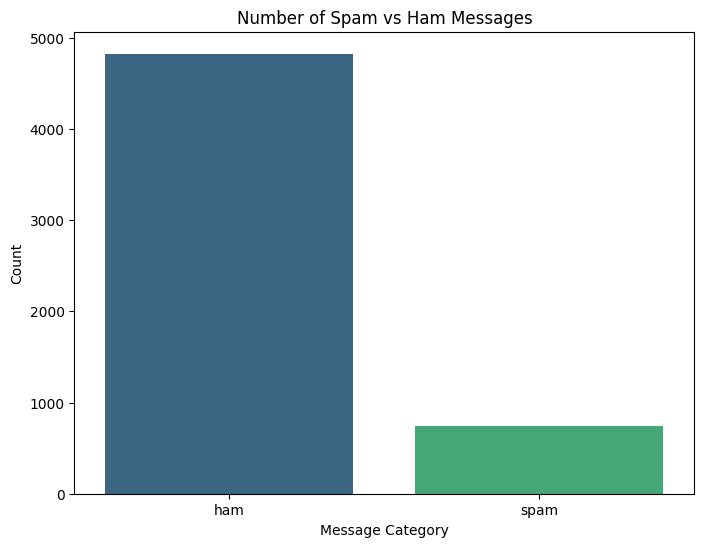

In [25]:
# Task 2: Visualize the Dataset
plt.figure(figsize=(8, 6))
sns.countplot(x='Category', data=df, palette='viridis')
plt.title('Number of Spam vs Ham Messages')
plt.xlabel('Message Category')
plt.ylabel('Count')
plt.show()

# Answer: Ham messages are typically more common in these datasets.

In [26]:
# Task 3: Prepare the Data
# Convert labels: Ham -> 0, Spam -> 1
df['Category_Num'] = df['Category'].map({'ham': 0, 'spam': 1})

X = df['Message']
y = df['Category_Num']

In [27]:
# Task 4: Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# We split the data to evaluate how the model performs on unseen data (generalization).

Training set size: 4457
Testing set size: 1115


In [28]:
# Task 5: Convert Text into Numbers
# Re-running this after fixing the data types in Task 1
cv = CountVectorizer(stop_words='english')
X_train_vec = cv.fit_transform(X_train)
X_test_vec = cv.transform(X_test)

In [29]:
# Task 6: Train a Machine Learning Model
# Retraining the model with the successfully vectorized data
model = LogisticRegression()
model.fit(X_train_vec, y_train)

LogisticRegression()

Model Accuracy: 98.57%


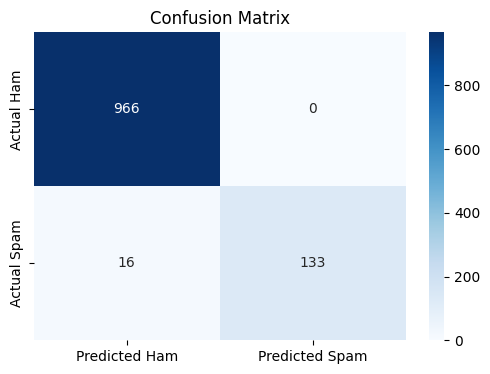

In [30]:
# Task 7 & 8: Make Predictions and Evaluate
predictions = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Plotting Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix')
plt.show()

In [31]:
# Task 9: Test Your Own SMS
user_input = input("Enter an SMS message to check: ")
input_vec = cv.transform([user_input])
prediction = model.predict(input_vec)

if prediction[0] == 0:
    print("\n📩 HAM MESSAGE")
else:
    print("\n🚨 SPAM MESSAGE")

Enter an SMS message to check: Don't forget to bring the project files tomorrow. We need to discuss them before the presentation

📩 HAM MESSAGE


In [32]:
#testing 2nd input
user_input = input("Enter an SMS message to check: ")
input_vec = cv.transform([user_input])
prediction = model.predict(input_vec)

if prediction[0] == 0:
    print("\n📩 HAM MESSAGE")
else:
    print("\n🚨 SPAM MESSAGE")

Enter an SMS message to check: "URGENT! Your account has been selected for a special cashback of ₹10,000. Verify your details immediately to receive the offer."

🚨 SPAM MESSAGE
